In [108]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
display(df.head())
df.info()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [109]:
import pandas as pd
import numpy as np

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

<Figure size 600x400 with 0 Axes>

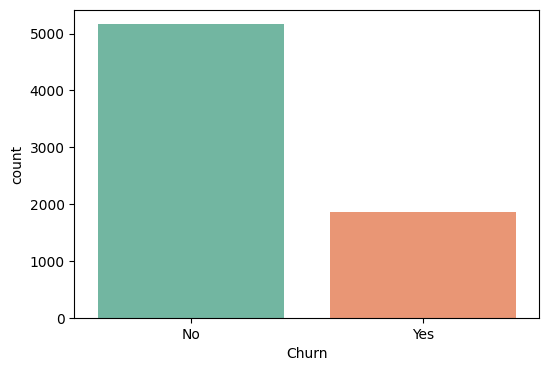

<Figure size 600x400 with 0 Axes>

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

(df['Churn'].value_counts(normalize=True) * 100)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn',hue='Churn', data=df, palette='Set2')
plt.figure(figsize=(6, 4))


In [111]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop('Churn', axis=1)
y = df['Churn']
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)
print(X.shape[1])
print(X_encoded.shape[1])
display(X_encoded.head(3))

19
30


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1


In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (5625, 30), y_train: (5625,)
X_test: (1407, 30), y_test: (1407,)


In [113]:
#LogisticRegression

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
param_grid = [
    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.01, 0.1, 1, 10]
    },
    {
        'model__solver': ['lbfgs'],
        'model__penalty': ['l2'], 
        'model__C': [0.01, 0.1, 1, 10]
    }
]
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,                       
    scoring='accuracy',
    n_jobs=-1               
)
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(format(grid_search.best_score_))
print(grid_search.cv_results_['mean_test_score'])

{'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
0.8030222222222223
[0.79555556 0.79928889 0.80124444 0.80124444 0.80284444 0.80248889
 0.80195556 0.80177778 0.80302222 0.80142222 0.80248889 0.80177778]


In [114]:
#LogisticRegression test

from sklearn.metrics import classification_report, confusion_matrix

test_score = grid_search.score(X_test, y_test)
print("Test Accuracy:")
print(test_score)

y_pred = grid_search.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy:
0.7981520966595593
Confusion Matrix:
[[924 109]
 [175 199]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [115]:
#LogisticRegression with class_weight

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',  
        C=0.01,
        penalty='l2',
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

pipe_balanced.fit(X_train, y_train)

y_pred = pipe_balanced.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Confusion Matrix:
[[736 297]
 [ 79 295]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



In [116]:
#LogisticRegression with SMOTE

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

smote_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(C=0.01, penalty='l2', solver='lbfgs', random_state=42))
])

smote_pipe.fit(X_train, y_train)

y_pred_smote = smote_pipe.predict(X_test)

print("Confusion Matrix (SMOTE):")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report (SMOTE):")
print(classification_report(y_test, y_pred_smote))

Confusion Matrix (SMOTE):
[[749 284]
 [ 89 285]]

Classification Report (SMOTE):
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1033
           1       0.50      0.76      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.75      1407



In [117]:
#A Quick RandomForest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,           
    max_depth=8,               
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1                 
)


rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


[[767 266]
 [ 81 293]]
              precision    recall  f1-score   support

           0       0.90      0.74      0.82      1033
           1       0.52      0.78      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.77      1407



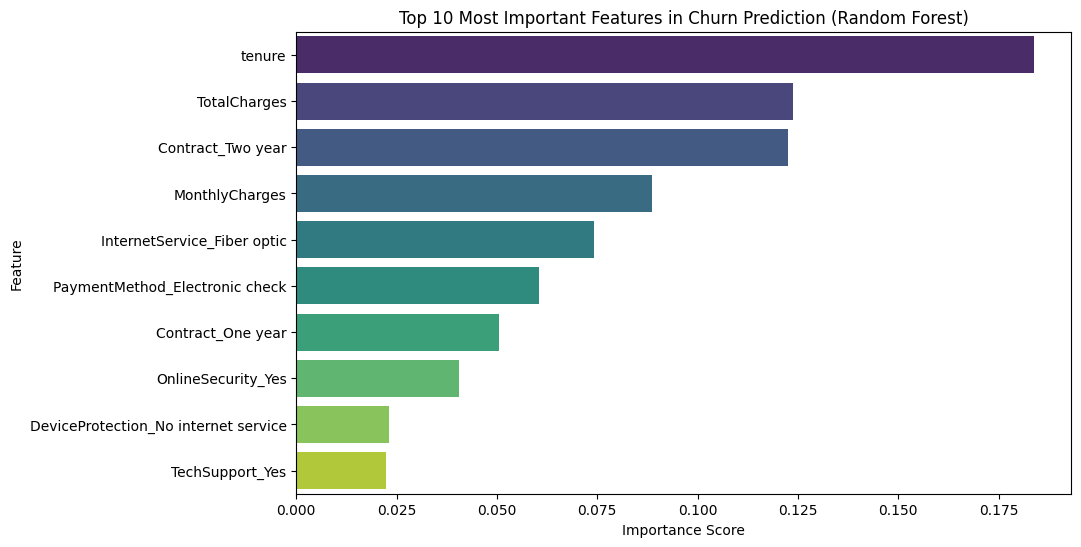

In [118]:
#extract feature_importance from RandomForest

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

top_10_features = feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_10_features.values, 
    y=top_10_features.index, 
    hue=top_10_features.index, 
    palette='viridis', 
    legend=False
)
plt.title('Top 10 Most Important Features in Churn Prediction (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


In [119]:
#feature Engineering

df_processed = df.copy()

df_processed['Avg_Monthly_Paid'] = df_processed['TotalCharges'] / (df_processed['tenure'] + 1)
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_processed['Total_Services_Count'] = (df_processed[services] == 'Yes').sum(axis=1)
df_processed['Tenure_Group'] = pd.cut(df_processed['tenure'], bins=[-1, 12, 24, 48, 72], labels=['0-12', '12-24', '24-48', '48+'])


display(df_processed.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Avg_Monthly_Paid,Total_Services_Count,Tenure_Group
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,14.925000,1,0-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,53.985714,2,24-48
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,36.050000,2,0-12
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.016304,3,24-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,50.550000,0,0-12


In [120]:
#encoding

from sklearn.model_selection import train_test_split

X_new = df_processed.drop('Churn', axis=1)
X_new_en = pd.get_dummies(X_new, drop_first=True, dtype=int)
                          
X_train_new, X_test_new, y_train, y_test = train_test_split(
    X_new_en, y, test_size=0.2, random_state=42, stratify=y
)



In [121]:
#RandomForest_New

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_fe = RandomForestClassifier(
    n_estimators=100, 
    max_depth=8, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)
rf_fe.fit(X_train_new, y_train)
y_pred_fe = rf_fe.predict(X_test_new)

print(confusion_matrix(y_test, y_pred_fe))
print(classification_report(y_test, y_pred_fe))


[[764 269]
 [ 85 289]]
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



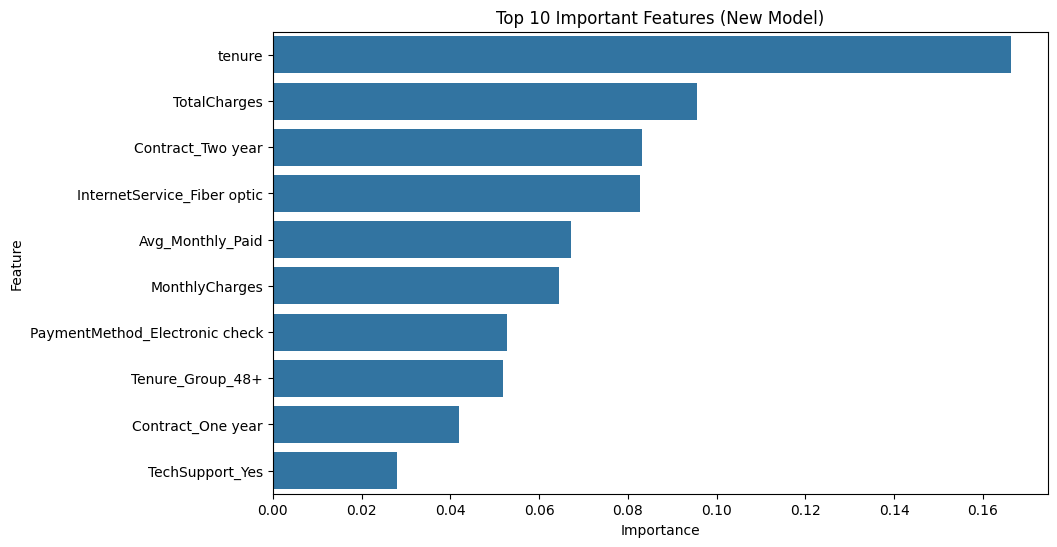

In [122]:
#Feature Importance from RandomForest_New

importances = rf_fe.feature_importances_
feature_names = X_train_new.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

top_10 = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10)
plt.title('Top 10 Important Features (New Model)')
plt.show()


In [123]:
#RandomForest_New Hypertunning

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, 16],
    'min_samples_leaf': [1, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='f1', 
    n_jobs=-1
)

grid_rf.fit(X_train_new, y_train)
grid_rf.best_params_

best_rf = grid_rf.best_estimator_
y_test_pred = best_rf.predict(X_test_new)

print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))




[[751 282]
 [ 83 291]]
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1033
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [124]:
#XGBoost (On Featured Data)

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators=100,         
    learning_rate=0.05,     
    max_depth=4,              
    scale_pos_weight=scale_pos_weight_value,  
    subsample=0.8,           
    colsample_bytree=0.8,      
    random_state=42,
    eval_metric='logloss'    
)

xgb_model.fit(X_train_new, y_train)

y_pred_xgb = xgb_model.predict(X_test_new)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_new)[:, 1]

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
auc = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"ROC-AUC Score: {auc:.4f}")


[[735 298]
 [ 72 302]]
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407

ROC-AUC Score: 0.8418


In [125]:
#XGBoost (On Featured Data) With Hypertunning

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

scale_pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()
param_distributions = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [scale_pos_weight_val * 0.8, scale_pos_weight_val, scale_pos_weight_val * 1.2]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_distributions,
    n_iter=25,              
    scoring='f1',           
    cv=5,                  
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train_new, y_train)
best_xgb = xgb_search.best_estimator_
y_pred_best = best_xgb.predict(X_test_new)
y_proba_best = best_xgb.predict_proba(X_test_new)[:, 1]

print(xgb_search.best_params_)


print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_best):.4f}")


Fitting 5 folds for each of 25 candidates, totalling 125 fits
{'subsample': 0.7, 'scale_pos_weight': np.float64(2.2100334448160535), 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
[[763 270]
 [ 82 292]]
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

ROC-AUC Score: 0.8421


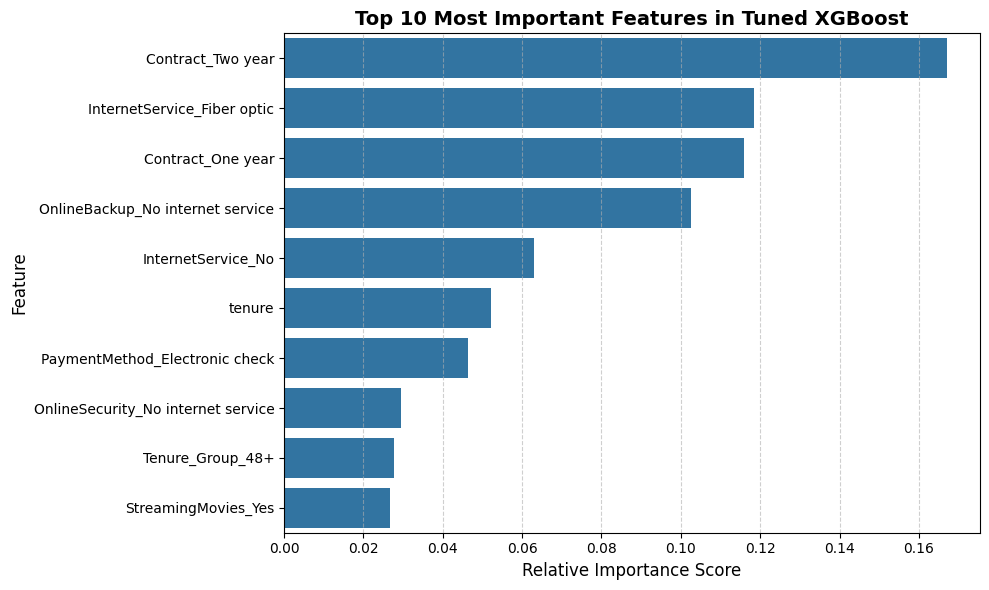

In [126]:
#Feature Importance from XGBoost

importance = best_xgb.feature_importances_
feature_names = X_train_new.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_df.head(10), 
    x='Importance', 
    y='Feature', 
)

plt.title('Top 10 Most Important Features in Tuned XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


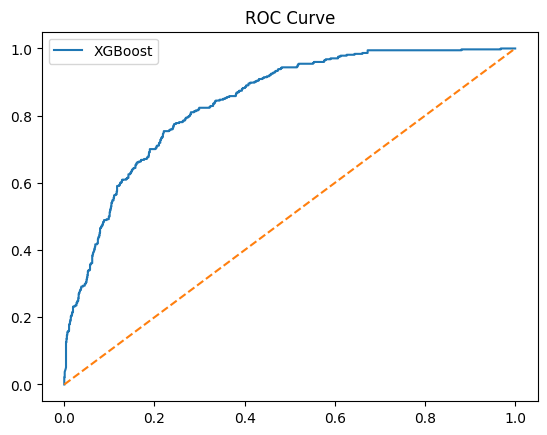

Threshold | Recall | Precision | Flagged
------------------------------------------
   0.3    |  0.90  |   0.44    |   764
   0.4    |  0.84  |   0.47    |   666
   0.5    |  0.78  |   0.52    |   562
   0.6    |  0.66  |   0.59    |   416
   0.7    |  0.49  |   0.65    |   280


In [127]:
#ROC Curve

from sklearn.metrics import roc_curve, recall_score, precision_score

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
plt.plot(fpr, tpr, label='XGBoost')
plt.plot([0, 1], [0, 1], '--')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("Threshold | Recall | Precision | Flagged")
print("-" * 42)

for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (y_proba_best >= thresh).astype(int)
    
    rec = recall_score(y_test, preds)
    prec = precision_score(y_test, preds)
    flagged = preds.sum()
    
    print(f"   {thresh}    |  {rec:.2f}  |   {prec:.2f}    |   {flagged}")



Threshold | Saved (TP) | Wasted (FP) | Missed (FN) | Net Profit ($)
-----------------------------------------------------------------
   0.20   |    355     |     535    |      19    |   $     8,397
   0.30   |    336     |     428    |      38    |   $     8,610
   0.40   |    316     |     350    |      58    |   $     7,968
   0.50   |    292     |     270    |      82    |   $     6,858
   0.60   |    247     |     169    |     127    |   $     3,551
   0.70   |    183     |      97    |     191    |   $    -2,943


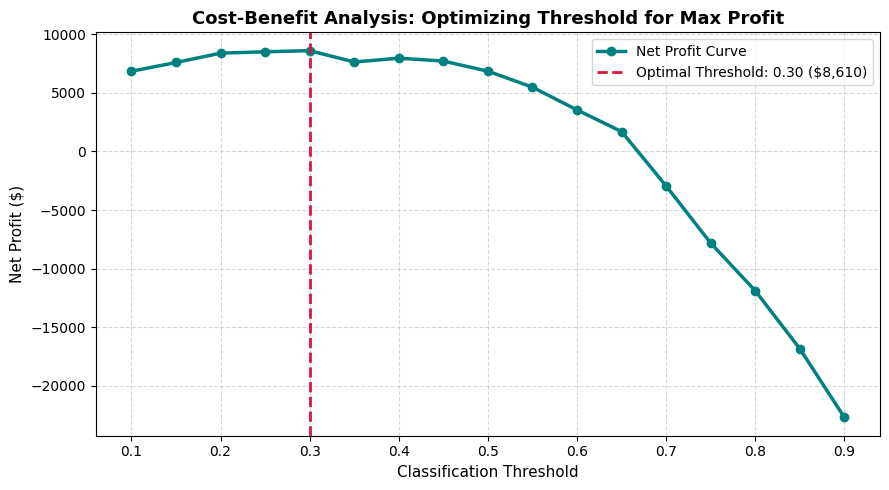

In [128]:
#Cost-Benefit Analysis

avg_monthly = df['MonthlyCharges'].mean()
offer_cost = 25  

thresholds = np.linspace(0.1, 0.9, 17)
net_profits = []

print("Threshold | Saved (TP) | Wasted (FP) | Missed (FN) | Net Profit ($)")
print("-" * 65)

for thresh in thresholds:
    preds = (y_proba_best >= thresh).astype(int)
    
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    
    profit = (tp * avg_monthly) - (fp * offer_cost) - (fn * avg_monthly)
    net_profits.append(profit)
    
    if round(thresh, 2) in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
        print(f"   {thresh:.2f}   |    {tp:3d}     |     {fp:3d}    |     {fn:3d}    |   ${profit:10,.0f}")

best_idx = np.argmax(net_profits)
best_thresh = thresholds[best_idx]
max_profit = net_profits[best_idx]

plt.figure(figsize=(9, 5))
plt.plot(thresholds, net_profits, marker='o', color='teal', lw=2.5, label='Net Profit Curve')
plt.axvline(best_thresh, color='crimson', linestyle='--', lw=2, 
            label=f'Optimal Threshold: {best_thresh:.2f} (${max_profit:,.0f})')

plt.title('Cost-Benefit Analysis: Optimizing Threshold for Max Profit', fontsize=13, fontweight='bold')
plt.xlabel('Classification Threshold', fontsize=11)
plt.ylabel('Net Profit ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()




In [129]:
import joblib
from sklearn.base import BaseEstimator, ClassifierMixin

class CustomThresholdModel(BaseEstimator, ClassifierMixin):
    def __init__(self, model, threshold=0.3):
        self.model = model
        self.threshold = threshold
        
    def predict(self, X):
        proba = self.model.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)
    
    def predict_proba(self, X):
        return self.model.predict_proba(X)

final_deployed_model = CustomThresholdModel(model=best_xgb, threshold=0.3)

joblib.dump(final_deployed_model, 'churn_model_xgb.pkl')
print("successful")


successful


In [130]:
from IPython.display import FileLink
import os

FileLink(r'churn_model_xgb.pkl')

/kaggle/working/churn_model_xgb.pkl